# 05 &mdash; Methodology Audit: Rolling vs Expanding Window

[`04_deployment_garch.ipynb`](04_deployment_garch.ipynb) fits GARCH(1,1)-t
at each of 60 origins using **expanding** windows (all history up to each
origin), and reports pooled empirical coverage at five nominal levels.
The live deployment in `coffee_forecast/deployment.py` does the same.

This notebook audits that methodology choice by running the *same*
backtest with a **rolling** 1,536-day training window at every origin,
and compares both configurations side-by-side on:

- pooled empirical coverage at 50%, 80%, 90%, 95%, and 99% nominal levels
- coverage-by-horizon at 80% and 95%
- the six fan-chart origins from notebook 04 (Dec 2001 — May 2025)
- fitted parameters $(\omega, \alpha, \beta, \nu)$ at every origin

The numbers in this notebook's pooled-coverage table (under the
`expanding` config) are the source of the 5-level coverage results
reported in the paper's Table II.

Investigation only: this notebook does not modify any production code.


## 1. Setup

In [1]:
import sys
from pathlib import Path

# Make `coffee_forecast` importable whether or not `pip install -e .`
# is in effect for this kernel. No-op when the package is already on
# sys.path (e.g. via the editable install); falls back to inserting
# the repo root so the notebook also runs from a fresh clone.
try:
    import coffee_forecast  # noqa: F401
except ModuleNotFoundError:
    sys.path.insert(0, str(Path.cwd().parent))

import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from arch import arch_model

from coffee_forecast import load_coffee_data, get_forecast_origins, std_t_ppf
from coffee_forecast.config import CSV_DIR, FIG_DIR, HORIZON, CONTEXT_LEN

CSV_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

ROLLING_LEN = 1536  # fixed-length rolling training window, in trading days

In [2]:
df = load_coffee_data()
print(f"{len(df)} prices  ({df['ds'].min().date()} → {df['ds'].max().date()})")

8104 prices  (1994-01-03 → 2026-01-30)


## 2. Forecast origins

Same 60 origins as notebook 04, so the two backtests are evaluated at
the same set of dates.

In [3]:
origins = get_forecast_origins(
    df, num_windows=60, context_len=CONTEXT_LEN, horizon=HORIZON
)
print(
    f"{len(origins)} origins, "
    f"from {df.iloc[origins[0]]['ds'].date()} to {df.iloc[origins[-1]]['ds'].date()}"
)

60 origins, from 2000-02-29 to 2025-10-13


## 3. Shared per-origin fit routine

One function fits GARCH(1,1)-t at a single origin and returns the
prediction-interval bands at every requested level, the fitted
$(\omega, \alpha, \beta, \nu, \mu)$, and the optimizer's convergence
status. The only thing that differs between the two configurations is
the training slice.

In [4]:
ALPHA_LEVELS = [0.50, 0.20, 0.10, 0.05, 0.01]
LEVELS_PCT = [50, 80, 90, 95, 99]


def garch_origin_fit(df, a, window_kind, horizon=HORIZON, alpha_levels=ALPHA_LEVELS):
    if window_kind == "expanding":
        ctx_prices = df.iloc[:a]["y"].values.astype(float)
    elif window_kind == "rolling":
        ctx_prices = df.iloc[a - ROLLING_LEN : a]["y"].values.astype(float)
    else:
        raise ValueError(f"unknown window_kind={window_kind!r}")

    ctx_log_ret = np.diff(np.log(ctx_prices))
    actual = df.iloc[a : a + horizon]["y"].values.astype(float)
    P0 = float(ctx_prices[-1])

    am = arch_model(ctx_log_ret * 100, mean="Constant", vol="Garch", p=1, q=1, dist="t")
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        fit = am.fit(disp="off", show_warning=False)
    convergence_warning = any("converge" in str(w.message).lower() for w in caught)

    nu = float(fit.params["nu"])
    var_fc = fit.forecast(horizon=horizon).variance.iloc[-1].values / 10_000.0
    mu_fr = fit.params["mu"] / 100.0
    cum_sd = np.sqrt(np.cumsum(var_fc))
    drift = mu_fr * np.arange(1, horizon + 1)
    point = P0 * np.exp(drift)

    bands = {}
    for alpha in alpha_levels:
        q = std_t_ppf(1 - alpha / 2, nu)
        spread = q * cum_sd
        pct = int(round((1 - alpha) * 100))
        bands[pct] = (P0 * np.exp(drift - spread), P0 * np.exp(drift + spread))

    params = {
        "omega": float(fit.params["omega"]),
        "alpha": float(fit.params["alpha[1]"]),
        "beta": float(fit.params["beta[1]"]),
        "nu": nu,
        "mu": float(fit.params["mu"]),
        "convergence_flag": int(fit.convergence_flag),
        "convergence_warning": convergence_warning,
    }
    return actual, point, bands, params

## 4. Run both configurations

In [5]:
results = {"expanding": [], "rolling": []}

for window_kind in ["expanding", "rolling"]:
    print(
        f"\nFitting GARCH(1,1)-t with {window_kind} window at {len(origins)} origins..."
    )
    for i, a in enumerate(origins, start=1):
        actual, point, bands, params = garch_origin_fit(df, a, window_kind)
        rec = {
            "origin_id": i,
            "origin_date": df.iloc[a]["ds"],
            "config": window_kind,
            "actual": actual,
            "point": point,
            "bands": bands,
            **params,
        }
        # Per-origin coverage at each level (fraction of the 63 steps inside the band).
        for pct in LEVELS_PCT:
            lo, hi = bands[pct]
            rec[f"cov_{pct}"] = float(((actual >= lo) & (actual <= hi)).mean())
        results[window_kind].append(rec)
        if i % 10 == 0:
            print(f"  ... {i}/{len(origins)} done")

print("\nAll fits complete.")


Fitting GARCH(1,1)-t with expanding window at 60 origins...
  ... 10/60 done
  ... 20/60 done
  ... 30/60 done
  ... 40/60 done
  ... 50/60 done
  ... 60/60 done

Fitting GARCH(1,1)-t with rolling window at 60 origins...
  ... 10/60 done
  ... 20/60 done
  ... 30/60 done
  ... 40/60 done
  ... 50/60 done
  ... 60/60 done

All fits complete.


## 5. Degenerate fits

Flag every origin where one of the following holds under either
configuration:

- $\nu < 2.5$ or $\nu > 30$ (degrees-of-freedom estimate at a boundary)
- $\alpha + \beta > 0.999$ (near non-stationarity of the conditional variance)
- `arch_model.fit()` raised a convergence warning, or the optimizer's
  convergence flag is non-zero

In [6]:
def is_nu_boundary(nu):
    return (nu < 2.5) or (nu > 30.0)


def is_near_nonstationary(alpha, beta):
    return (alpha + beta) > 0.999


flag_rows = []
for config in ["expanding", "rolling"]:
    for rec in results[config]:
        flags = []
        if is_nu_boundary(rec["nu"]):
            flags.append(f"nu={rec['nu']:.2f}")
        if is_near_nonstationary(rec["alpha"], rec["beta"]):
            flags.append(f"alpha+beta={rec['alpha'] + rec['beta']:.4f}")
        if rec["convergence_warning"] or rec["convergence_flag"] != 0:
            flags.append(
                f"conv_flag={rec['convergence_flag']} warn={rec['convergence_warning']}"
            )
        if flags:
            flag_rows.append(
                {
                    "config": config,
                    "origin_id": rec["origin_id"],
                    "origin_date": rec["origin_date"].strftime("%Y-%m-%d"),
                    "issue": "; ".join(flags),
                }
            )

if flag_rows:
    print("Degenerate fits flagged:")
    print(pd.DataFrame(flag_rows).to_string(index=False))
else:
    print("No degenerate fits under either configuration.")

Degenerate fits flagged:
 config  origin_id origin_date             issue
rolling         18  2007-08-31 alpha+beta=0.9997


## 6. Pooled empirical coverage

Pooled coverage = fraction of all $60 \times 63 = 3{,}780$ realized
(origin, step) pairs that fall inside each band. Equivalent to the mean
of the per-origin coverage rates.

In [7]:
pooled_rows = []
for pct in LEVELS_PCT:
    row = {"nominal_pct": pct}
    for config in ["expanding", "rolling"]:
        hits = np.concatenate(
            [
                (rec["actual"] >= rec["bands"][pct][0])
                & (rec["actual"] <= rec["bands"][pct][1])
                for rec in results[config]
            ]
        )
        row[f"{config}_empirical_pct"] = 100.0 * float(hits.mean())
    row["diff_rolling_minus_expanding_pp"] = (
        row["rolling_empirical_pct"] - row["expanding_empirical_pct"]
    )
    pooled_rows.append(row)

pooled_df = pd.DataFrame(pooled_rows)
print(pooled_df.to_string(index=False, float_format=lambda v: f"{v:7.2f}"))

 nominal_pct  expanding_empirical_pct  rolling_empirical_pct  diff_rolling_minus_expanding_pp
          50                    49.15                  48.76                            -0.40
          80                    78.76                  75.05                            -3.70
          90                    90.79                  86.96                            -3.84
          95                    97.20                  94.55                            -2.65
          99                    99.84                  99.68                            -0.16


## 7. Coverage-by-horizon — side-by-side

Same two-panel layout as the figure in notebook 04 cell 24, drawn once
per configuration so the horizon-by-horizon shape can be eyeballed.

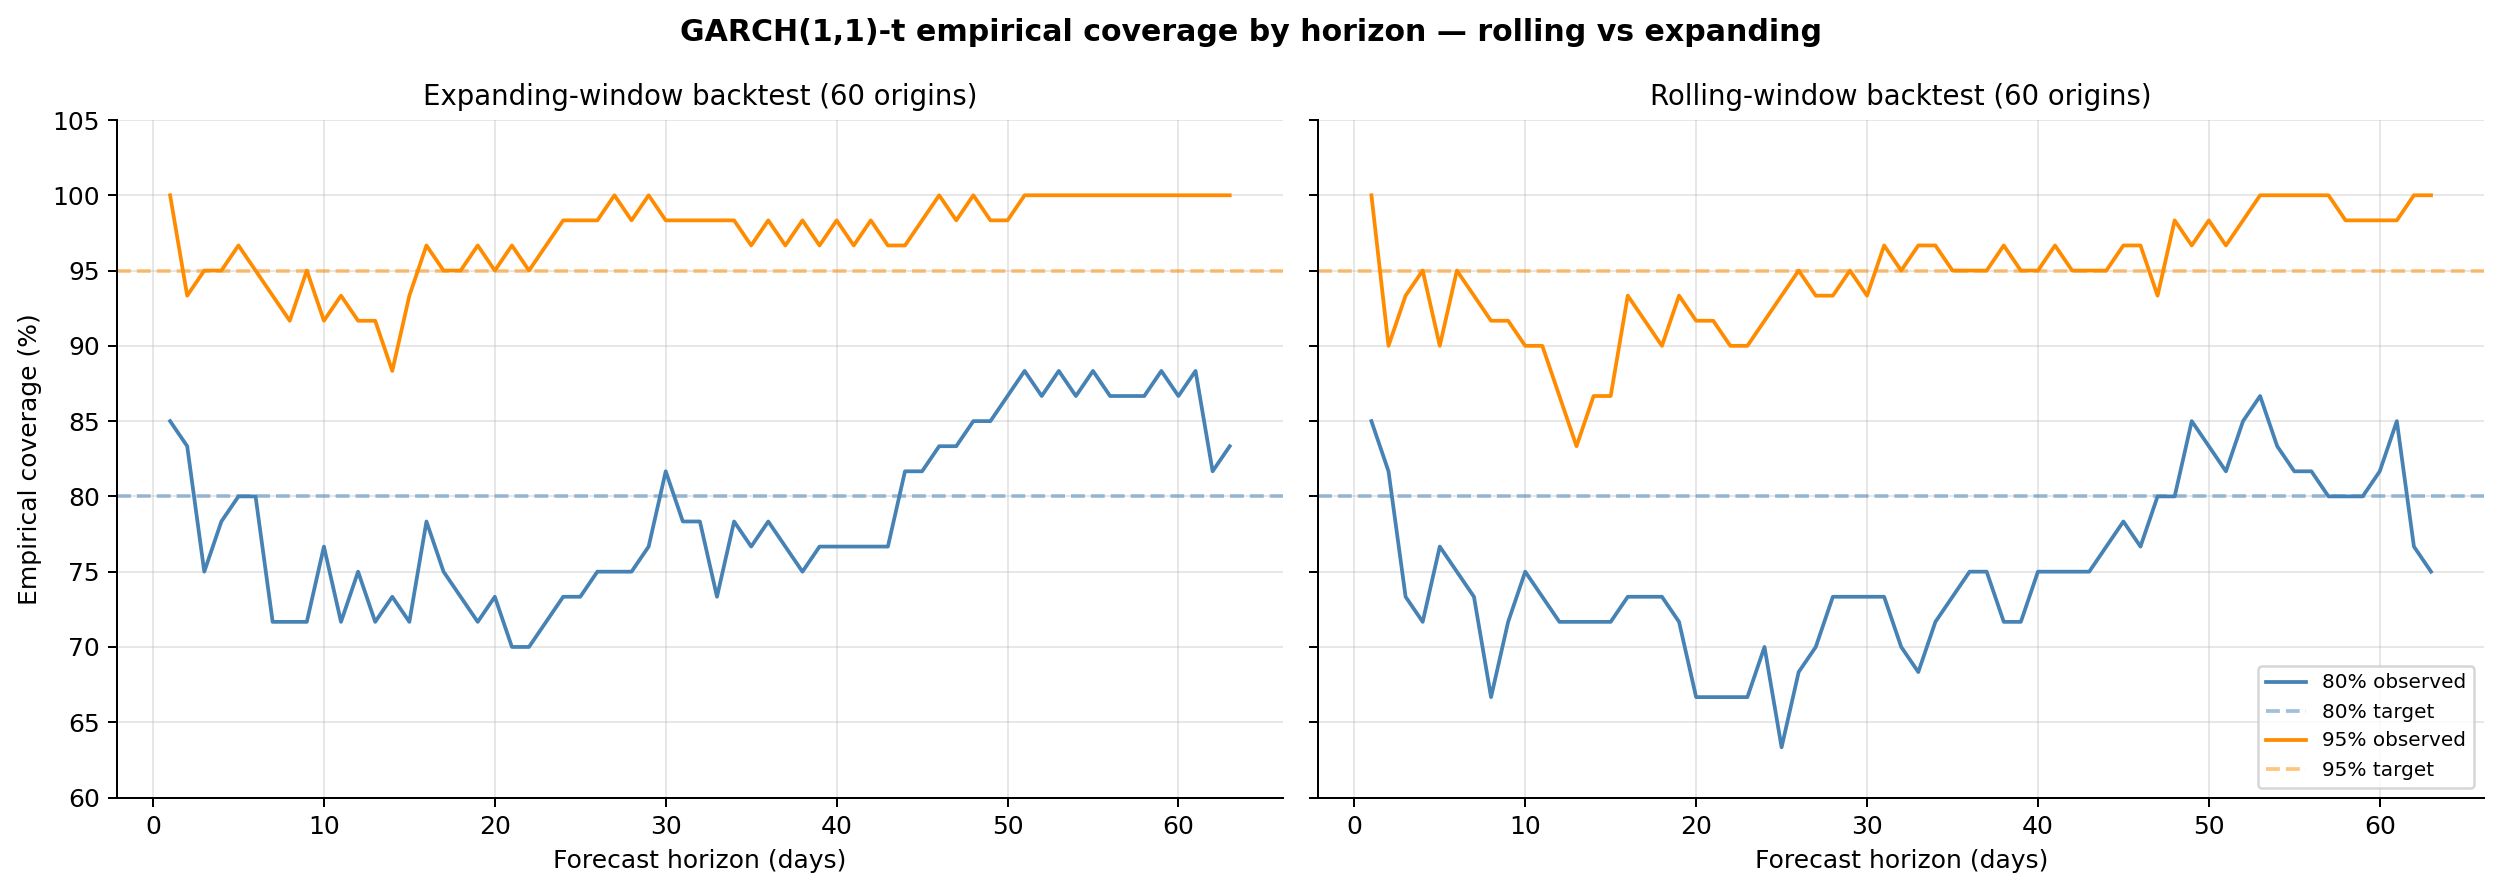

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=180, sharey=True)
steps = np.arange(1, HORIZON + 1)

for ax, config in zip(axes, ["expanding", "rolling"]):
    for pct, color in [(80, "steelblue"), (95, "darkorange")]:
        cov_matrix = np.array(
            [
                (rec["actual"] >= rec["bands"][pct][0])
                & (rec["actual"] <= rec["bands"][pct][1])
                for rec in results[config]
            ]
        )
        by_step = cov_matrix.mean(axis=0)
        ax.plot(steps, by_step * 100, color=color, lw=1.5, label=f"{pct}% observed")
        ax.axhline(pct, color=color, ls="--", alpha=0.5, label=f"{pct}% target")
    ax.set_xlabel("Forecast horizon (days)")
    ax.set_title(f"{config.capitalize()}-window backtest (60 origins)", fontsize=11)
    ax.set_ylim(60, 105)
    ax.grid(alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylabel("Empirical coverage (%)")
axes[1].legend(loc="lower right", fontsize=8)
fig.suptitle(
    "GARCH(1,1)-t empirical coverage by horizon — rolling vs expanding",
    fontsize=12,
    weight="semibold",
)
fig.tight_layout()
fig.savefig(FIG_DIR / "rolling_vs_expanding_coverage.png", dpi=300, bbox_inches="tight")
plt.show()

## 8. The six fan-chart origins

Origins 5, 26, 38, 44, 52, 59 are the six panels in notebook 04's
`garch_sample_forecasts.png`. For each, compare the 95% PI width at
the longest horizon ($h = 63$) under both configurations.

In [9]:
FANCHART_ORIGIN_IDS = [5, 26, 38, 44, 52, 59]

width_rows = []
for oid in FANCHART_ORIGIN_IDS:
    exp_rec = next(r for r in results["expanding"] if r["origin_id"] == oid)
    rol_rec = next(r for r in results["rolling"] if r["origin_id"] == oid)
    lo_e, hi_e = exp_rec["bands"][95]
    lo_r, hi_r = rol_rec["bands"][95]
    width_rows.append(
        {
            "origin_id": oid,
            "origin_date": exp_rec["origin_date"].strftime("%b %Y"),
            "expanding_pi95_h63": float(hi_e[-1] - lo_e[-1]),
            "rolling_pi95_h63": float(hi_r[-1] - lo_r[-1]),
            "ratio_rolling_over_expanding": float(
                (hi_r[-1] - lo_r[-1]) / (hi_e[-1] - lo_e[-1])
            ),
        }
    )

width_df = pd.DataFrame(width_rows)
print(width_df.to_string(index=False, float_format=lambda v: f"{v:7.3f}"))

 origin_id origin_date  expanding_pi95_h63  rolling_pi95_h63  ratio_rolling_over_expanding
         5    Dec 2001              40.296            38.414                         0.953
        26    Mar 2011             202.149           172.962                         0.856
        38    May 2016              84.621            74.739                         0.883
        44    Dec 2018              79.061            72.375                         0.915
        52    May 2022             190.157           177.435                         0.933
        59    May 2025             295.643           294.021                         0.995


## 9. Save outputs

In [10]:
csv_rows = []
for config in ["expanding", "rolling"]:
    for rec in results[config]:
        lo95, hi95 = rec["bands"][95]
        csv_rows.append(
            {
                "config": config,
                "origin_id": rec["origin_id"],
                "origin_date": rec["origin_date"].strftime("%Y-%m-%d"),
                "omega": rec["omega"],
                "alpha": rec["alpha"],
                "beta": rec["beta"],
                "alpha_plus_beta": rec["alpha"] + rec["beta"],
                "nu": rec["nu"],
                "mu": rec["mu"],
                "convergence_flag": rec["convergence_flag"],
                "convergence_warning": rec["convergence_warning"],
                "nu_boundary": is_nu_boundary(rec["nu"]),
                "near_nonstationary": is_near_nonstationary(rec["alpha"], rec["beta"]),
                "cov_50": rec["cov_50"],
                "cov_80": rec["cov_80"],
                "cov_90": rec["cov_90"],
                "cov_95": rec["cov_95"],
                "cov_99": rec["cov_99"],
                "pi95_width_h63": float(hi95[-1] - lo95[-1]),
            }
        )

out_df = pd.DataFrame(csv_rows)
csv_path = CSV_DIR / "rolling_vs_expanding_comparison.csv"
out_df.to_csv(csv_path, index=False)
print(f"Wrote {csv_path}  ({len(out_df)} rows)")
print(f"Wrote {FIG_DIR / 'rolling_vs_expanding_coverage.png'}")

Wrote /Users/bridgetbrinkman/Documents/University of Pittsburgh/Spring 2026/MATH 1103 Big Problems/coffee-futures-forecasting-model/results/csv/rolling_vs_expanding_comparison.csv  (120 rows)
Wrote /Users/bridgetbrinkman/Documents/University of Pittsburgh/Spring 2026/MATH 1103 Big Problems/coffee-futures-forecasting-model/results/figures/rolling_vs_expanding_coverage.png


## 10. Summary

In [11]:
# (a) Degenerate fits under rolling
rolling_recs = results["rolling"]
n_nu_bound = sum(1 for r in rolling_recs if is_nu_boundary(r["nu"]))
n_near_ns = sum(1 for r in rolling_recs if is_near_nonstationary(r["alpha"], r["beta"]))
n_conv = sum(
    1 for r in rolling_recs if r["convergence_warning"] or r["convergence_flag"] != 0
)

# (b) Pooled coverage difference per level
diff_text = ", ".join(
    f"{int(row['nominal_pct'])}% → {row['diff_rolling_minus_expanding_pp']:+.1f} pp"
    for _, row in pooled_df.iterrows()
)
max_abs_diff_pp = pooled_df["diff_rolling_minus_expanding_pp"].abs().max()

# (c) Qualitative shape of coverage-by-horizon
# Measure the largest per-step coverage gap between configs at the 80% and 95% levels.
step_gap_max = 0.0
for pct in (80, 95):
    by_step = {}
    for config in ["expanding", "rolling"]:
        cov_matrix = np.array(
            [
                (rec["actual"] >= rec["bands"][pct][0])
                & (rec["actual"] <= rec["bands"][pct][1])
                for rec in results[config]
            ]
        )
        by_step[config] = cov_matrix.mean(axis=0) * 100
    step_gap_max = max(
        step_gap_max, float(np.abs(by_step["rolling"] - by_step["expanding"]).max())
    )
shape_verdict = (
    "qualitatively different" if step_gap_max > 5.0 else "qualitatively similar"
)

# (d) 6-panel fan-chart bands
ratios = [r["ratio_rolling_over_expanding"] for r in width_rows]
mean_ratio = float(np.mean(ratios))
ratio_lo, ratio_hi = float(min(ratios)), float(max(ratios))
fan_verdict = (
    "would visibly differ"
    if abs(mean_ratio - 1.0) > 0.10 or ratio_hi > 1.20 or ratio_lo < 0.80
    else "would look qualitatively similar"
)

summary = (
    f"(a) Rolling-window degenerate fits: {n_nu_bound} with ν at boundary "
    f"(<2.5 or >30), {n_near_ns} with α+β > 0.999, {n_conv} with convergence "
    f"warnings or non-zero convergence flag. "
    f"(b) Pooled coverage shift (rolling − expanding): {diff_text}; largest "
    f"absolute deviation across nominal levels is {max_abs_diff_pp:.1f} pp. "
    f"(c) Coverage-by-horizon shape is {shape_verdict} (largest per-step gap "
    f"across the 80% and 95% curves: {step_gap_max:.1f} pp). "
    f"(d) Across the six fan-chart origins, the 95% PI width at h=63 has "
    f"rolling/expanding ratios from {ratio_lo:.2f} to {ratio_hi:.2f} "
    f"(mean {mean_ratio:.2f}); the six panels {fan_verdict}."
)
print(summary)

(a) Rolling-window degenerate fits: 0 with ν at boundary (<2.5 or >30), 1 with α+β > 0.999, 0 with convergence warnings or non-zero convergence flag. (b) Pooled coverage shift (rolling − expanding): 50% → -0.4 pp, 80% → -3.7 pp, 90% → -3.8 pp, 95% → -2.6 pp, 99% → -0.2 pp; largest absolute deviation across nominal levels is 3.8 pp. (c) Coverage-by-horizon shape is qualitatively different (largest per-step gap across the 80% and 95% curves: 10.0 pp). (d) Across the six fan-chart origins, the 95% PI width at h=63 has rolling/expanding ratios from 0.86 to 0.99 (mean 0.92); the six panels would look qualitatively similar.
